In [2]:
# Run this cell first to install all required packages
!pip install -q asyncpraw pandas numpy matplotlib seaborn
!pip install -q sentence-transformers scikit-learn umap-learn hdbscan
!pip install -q bertopic datasets openai
!pip install -q transformers torch accelerate
!pip install -q wordcloud plotly
!pip install -q huggingface_hub
!pip install --upgrade transformers
!pip install --upgrade torch
!pip install git+https://github.com/huggingface/transformers.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 37.6 MB/s eta 0:00:00
  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-jxhzxseu
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-jxhzxseu
  Resolved https://github.com/huggingface/transformers.git to commit bdee0889714e9cb3e53d3b1b2a626919479d356c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached huggingface_hub-1.1.5-py3-none-any.whl.metadata (13 kB)
Using cached huggingface_hub-1.1.5-py3-none-any.whl (516 kB)
  Created wheel for transformers: filename=transformers-5.0.0.dev0-py3-none-any.whl size=11085249 sha256=98784d8085f07c5a53024161c21689051bac08ba27f6e244210c70aef1

In [ ]:
import asyncio
import asyncpraw
import pandas as pd
import numpy as np
from datetime import datetime
import re

# Initialize Reddit API (using the provided credentials)
async def fetch_reddit_data():
    """Fetch Reddit thread and comments data"""
    reddit = asyncpraw.Reddit(
        client_id="CLIENT_ID_HERE",
        client_secret="Secret_KEY_HERE",
        user_agent="gpt5_ama_clustering/TraditionalAbility68"
    )

    submission = await reddit.submission(
        url="https://www.reddit.com/r/ChatGPT/comments/1mkae1l/gpt5_ama_with_openais_sam_altman_and_some_of_the/"
    )
    await submission.load()

    # Get main post data
    main_post = {
        "id": submission.id,
        "title": submission.title,
        "selftext": submission.selftext,
        "author": submission.author.name if submission.author else None,
        "created_utc": submission.created_utc,
        "score": submission.score,
        "num_comments": submission.num_comments,
        "type": "main_post"
    }

    # Get comments
    await submission.comments.replace_more(limit=None)
    all_comments = submission.comments.list()

    # Process comments (limiting to 2000 for performance)
    comments_data = []
    for comment in all_comments[:2000]:
        if hasattr(comment, 'body') and comment.body not in ["[removed]", "[deleted]"]:
            comments_data.append({
                "id": comment.id,
                "parent_id": comment.parent_id,
                "author": comment.author.name if comment.author else None,
                "created_utc": comment.created_utc,
                "body": comment.body,
                "score": comment.score,
                "type": "comment"
            })

    return main_post, comments_data

# Fetch the data
main_post, comments = await fetch_reddit_data()
print(f"Collected main post and {len(comments)} comments")

Collected main post and 1985 comments


In [5]:
# BUILD DATAFRAME & TEXT PROCESSING PIPELINE

import re
from datetime import datetime

def preprocess_text(raw_text):
    """
    Clean raw Reddit text by removing noise such as URLs, markdown, and mentions.
    """
    if pd.isna(raw_text) or raw_text.strip() == "":
        return ""

    cleaned = raw_text

    # Remove external links and references
    cleaned = re.sub(r"http\S+", "", cleaned)        # URLs
    cleaned = re.sub(r"u\/\S+", "", cleaned)         # user mentions
    cleaned = re.sub(r"r\/\S+", "", cleaned)         # subreddit references
    cleaned = re.sub(r"\*\*(.*?)\*\*", r"\1", cleaned)  # bold markdown
    cleaned = re.sub(r"\[(.*?)\]\(.+?\)", r"\1", cleaned) # markdown links

    # Remove excessive whitespace
    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    return cleaned


# ----------------- DATAFRAME CONSTRUCTION -----------------

records = []

# Add main thread object
records.append({
    "id": main_post["id"],
    "text": main_post["selftext"],
    "title": main_post.get("title", ""),
    "author": main_post["author"],
    "created_utc": main_post["created_utc"],
    "score": main_post["score"],
    "entry_type": main_post["type"]
})

# Append all extracted comments
for c in comments:
    records.append({
        "id": c["id"],
        "text": c["body"],
        "title": "",
        "author": c["author"],
        "created_utc": c["created_utc"],
        "score": c["score"],
        "entry_type": c["type"]
    })

# Convert into a DataFrame
df = pd.DataFrame(records)

# Apply text cleaning
df["processed_text"] = df["text"].apply(preprocess_text)

# Drop extremely short messages (noise filtering)
df = df[df["processed_text"].str.len() >= 10].reset_index(drop=True)

# Convert timestamps for readability
df["timestamp"] = pd.to_datetime(df["created_utc"], unit="s")

# Summary output
print(f"Total processed entries: {len(df)} ready for NLP")
print(f"Timeframe: {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Score distribution: {df['score'].min()} to {df['score'].max()}\n")

# Show a preview
print("Sample records:")
print(df[["entry_type", "score", "processed_text"]].head())


Total processed entries: 1972 ready for NLP
Timeframe: 2025-08-07 20:01:28  →  2025-09-29 20:42:27
Score distribution: 1 to 1837

Sample records:
  entry_type  score                                     processed_text
0  main_post   1837  Ask us anything about GPT-5, but don’t ask us ...
1    comment      1  This AMA has been verified by the mod team and...
2    comment    870  Can you do something about the filter? Surely ...
3    comment    137  GPT has helped me in so many ways. I have auti...
4    comment    898  Why are we getting rid of the variants and 4o ...


In [6]:
from sentence_transformers import SentenceTransformer
import torch

# Select GPU when available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Embedding model setup
embedding_model_1 = SentenceTransformer("BAAI/bge-base-en-v1.5")
embedding_model_1.to(device)
model_1_name = "BAAI/bge-base-en-v1.5"

# Encode text into embeddings
texts_list = df["processed_text"].tolist()
embeddings_1 = embedding_model_1.encode(
    texts_list,
    convert_to_numpy=True,
    batch_size=32,
    show_progress_bar=True
)

print(f"Embeddings shape: {embeddings_1.shape}")


ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f848b5686b0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f8490d4e810>, 5735.917721876)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f848b56bc20>


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Embeddings shape: (1972, 768)


In [7]:
from sentence_transformers import SentenceTransformer

# Load second embedding model (strong for long conversation context)
embedding_model_2 = SentenceTransformer(
    "nomic-ai/nomic-embed-text-v1.5",
    trust_remote_code=True
)
embedding_model_2.to(device)
model_2_name = "nomic-ai/nomic-embed-text-v1.5"

# Generate embeddings using model 2
encoded_vectors_2 = embedding_model_2.encode(
    texts_list,          # input text data
    convert_to_numpy=True,
    batch_size=32,       # efficient batch processing
    show_progress_bar=True
)

print(f"Embeddings (model 2) shape: {encoded_vectors_2.shape}")


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Embeddings (model 2) shape: (1972, 768)


In [8]:
from sklearn.decomposition import PCA
from umap import UMAP
import matplotlib.pyplot as plt

print("Running PCA...")

# PCA dimensionality reduction (Model 1)
pca_m1 = PCA(n_components=50, random_state=42)
reduced_pca_m1 = pca_m1.fit_transform(embeddings_1)

pca_2d_m1 = PCA(n_components=2, random_state=42)        # 2D for visualization
reduced_pca_2d_m1 = pca_2d_m1.fit_transform(embeddings_1)

# PCA dimensionality reduction (Model 2)
pca_m2 = PCA(n_components=50, random_state=42)
reduced_pca_m2 = pca_m2.fit_transform(encoded_vectors_2)

pca_2d_m2 = PCA(n_components=2, random_state=42)
reduced_pca_2d_m2 = pca_2d_m2.fit_transform(encoded_vectors_2)

print(f"PCA output - Model 1: {reduced_pca_m1.shape}")
print(f"PCA output - Model 2: {reduced_pca_m2.shape}")

print("Running UMAP...")

# UMAP embedding (Model 1)
umap_m1 = UMAP(n_components=50, min_dist=0.0, metric="cosine", random_state=42)
reduced_umap_m1 = umap_m1.fit_transform(embeddings_1)

umap_2d_m1 = UMAP(n_components=2, min_dist=0.0, metric="cosine", random_state=42)
reduced_umap_2d_m1 = umap_2d_m1.fit_transform(embeddings_1)

# UMAP embedding (Model 2)
umap_m2 = UMAP(n_components=50, min_dist=0.0, metric="cosine", random_state=42)
reduced_umap_m2 = umap_m2.fit_transform(encoded_vectors_2)

umap_2d_m2 = UMAP(n_components=2, min_dist=0.0, metric="cosine", random_state=42)
reduced_umap_2d_m2 = umap_2d_m2.fit_transform(encoded_vectors_2)

print(f"UMAP output - Model 1: {reduced_umap_m1.shape}")
print(f"UMAP output - Model 2: {reduced_umap_m2.shape}")


Running PCA...
PCA output - Model 1: (1972, 50)
PCA output - Model 2: (1972, 50)
Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output - Model 1: (1972, 50)
UMAP output - Model 2: (1972, 50)


In [9]:
from sklearn.cluster import KMeans, DBSCAN
from hdbscan import HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Prepare embedding variations
datasets = {
    f"PCA_{model_1_name.split('/')[-1]}": reduced_pca_m1,
    f"PCA_{model_2_name.split('/')[-1]}": reduced_pca_m2,
    f"UMAP_{model_1_name.split('/')[-1]}": reduced_umap_m1,
    f"UMAP_{model_2_name.split('/')[-1]}": reduced_umap_m2
}

# Define clustering models
clusterers = {
    "KMeans": KMeans(n_clusters=8, random_state=42, n_init=10),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=5),
    "HDBSCAN": HDBSCAN(min_cluster_size=15, metric="euclidean", cluster_selection_method="eom")
}

# Store outputs for analysis
cluster_results = {}

print("Starting clustering trials...")
print("-" * 60)

# Run clustering for every dataset + algorithm pair
for label, embed_matrix in datasets.items():
    cluster_results[label] = {}

    for alg_name, alg_init in clusterers.items():
        print(f"Evaluating: {label} using {alg_name}")

        # Build fresh instance per execution
        if alg_name == "KMeans":
            model = KMeans(n_clusters=8, random_state=42, n_init=10)
        elif alg_name == "DBSCAN":
            model = DBSCAN(eps=0.5, min_samples=5)
        else:
            model = HDBSCAN(min_cluster_size=15, metric="euclidean", cluster_selection_method="eom")

        # Predict cluster labels
        labels_pred = model.fit_predict(embed_matrix)

        # Metrics calculation
        cluster_count = len(set(labels_pred)) - (1 if -1 in labels_pred else 0)
        noise_count = list(labels_pred).count(-1)

        if cluster_count > 1:
            mask = labels_pred != -1  # ignore noise for scoring
            if mask.sum() > 1:
                silhouette = silhouette_score(embed_matrix[mask], labels_pred[mask])
                ch_index = calinski_harabasz_score(embed_matrix[mask], labels_pred[mask])
            else:
                silhouette, ch_index = -1, -1
        else:
            silhouette, ch_index = -1, -1

        # Save results
        cluster_results[label][alg_name] = {
            "clusters": labels_pred,
            "n_clusters": cluster_count,
            "n_noise": noise_count,
            "silhouette_score": silhouette,
            "calinski_harabasz_score": ch_index
        }

        print(f" → Cluster count: {cluster_count}, Noise: {noise_count}")
        print(f" → Silhouette: {silhouette:.3f}, CH Index: {ch_index:.2f}\n")


Starting clustering trials...
------------------------------------------------------------
Evaluating: PCA_bge-base-en-v1.5 using KMeans
 → Cluster count: 8, Noise: 0
 → Silhouette: 0.067, CH Index: 94.97

Evaluating: PCA_bge-base-en-v1.5 using DBSCAN
 → Cluster count: 3, Noise: 149
 → Silhouette: 0.056, CH Index: 5.46

Evaluating: PCA_bge-base-en-v1.5 using HDBSCAN


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 → Cluster count: 2, Noise: 1659
 → Silhouette: 0.307, CH Index: 88.63

Evaluating: PCA_nomic-embed-text-v1.5 using KMeans
 → Cluster count: 8, Noise: 0
 → Silhouette: 0.073, CH Index: 103.09

Evaluating: PCA_nomic-embed-text-v1.5 using DBSCAN
 → Cluster count: 0, Noise: 1972
 → Silhouette: -1.000, CH Index: -1.00

Evaluating: PCA_nomic-embed-text-v1.5 using HDBSCAN


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 → Cluster count: 2, Noise: 1470
 → Silhouette: 0.202, CH Index: 34.15

Evaluating: UMAP_bge-base-en-v1.5 using KMeans
 → Cluster count: 8, Noise: 0
 → Silhouette: 0.368, CH Index: 1028.45

Evaluating: UMAP_bge-base-en-v1.5 using DBSCAN
 → Cluster count: 5, Noise: 17
 → Silhouette: -0.093, CH Index: 85.49

Evaluating: UMAP_bge-base-en-v1.5 using HDBSCAN


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 → Cluster count: 2, Noise: 6
 → Silhouette: 0.369, CH Index: 275.34

Evaluating: UMAP_nomic-embed-text-v1.5 using KMeans
 → Cluster count: 8, Noise: 0
 → Silhouette: 0.427, CH Index: 1220.25

Evaluating: UMAP_nomic-embed-text-v1.5 using DBSCAN
 → Cluster count: 4, Noise: 18
 → Silhouette: -0.059, CH Index: 104.17

Evaluating: UMAP_nomic-embed-text-v1.5 using HDBSCAN


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 → Cluster count: 21, Noise: 759
 → Silhouette: 0.603, CH Index: 1670.31



In [10]:
import pandas as pd

summary = []

# Traverse stored metrics
for emb_name, alg_data in cluster_results.items():
    for alg_name, stats in alg_data.items():
        summary.append({
            "Embedding": emb_name,
            "Algorithm": alg_name,
            "Clusters": stats["n_clusters"],
            "Noise Points": stats["n_noise"],
            "Silhouette Score": stats["silhouette_score"],
            "Calinski-Harabasz Score": stats["calinski_harabasz_score"]
        })

# Convert to DataFrame
results_df = pd.DataFrame(summary)

# Sort by silhouette descending for clarity
results_df = results_df.sort_values("Silhouette Score", ascending=False)

print("\nCLUSTERING RESULT SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv("clustering_results_summary.csv", index=False)
print("\nResults stored in clustering_results_summary.csv")



CLUSTERING RESULT SUMMARY
                 Embedding Algorithm  Clusters  Noise Points  Silhouette Score  Calinski-Harabasz Score
UMAP_nomic-embed-text-v1.5   HDBSCAN        21           759          0.602543              1670.311279
UMAP_nomic-embed-text-v1.5    KMeans         8             0          0.427499              1220.251831
     UMAP_bge-base-en-v1.5   HDBSCAN         2             6          0.369035               275.341278
     UMAP_bge-base-en-v1.5    KMeans         8             0          0.367935              1028.452515
      PCA_bge-base-en-v1.5   HDBSCAN         2          1659          0.306590                88.632355
 PCA_nomic-embed-text-v1.5   HDBSCAN         2          1470          0.201632                34.146683
 PCA_nomic-embed-text-v1.5    KMeans         8             0          0.073168               103.086411
      PCA_bge-base-en-v1.5    KMeans         8             0          0.067372                94.967026
      PCA_bge-base-en-v1.5    DBSCAN 

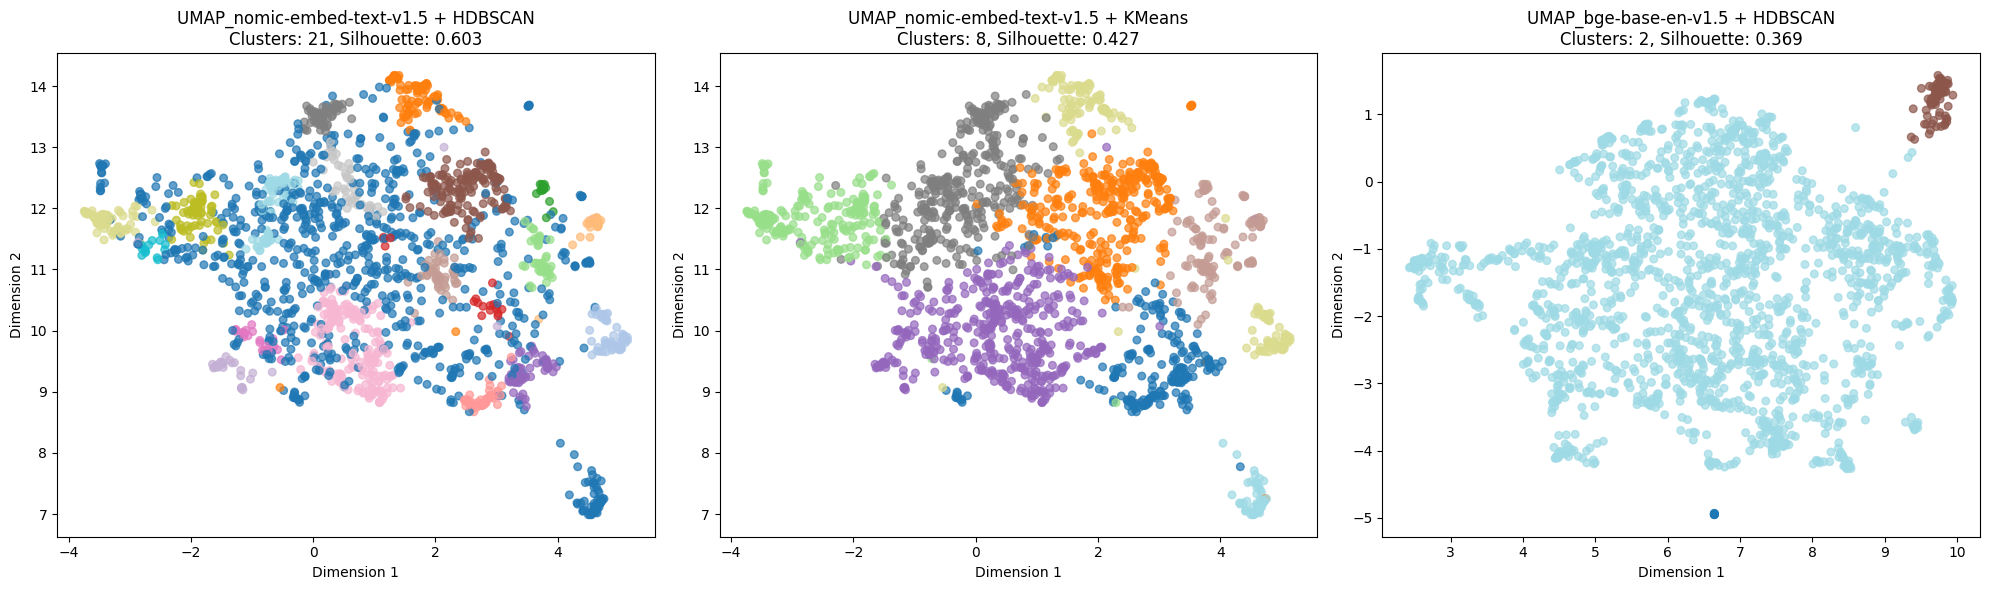

In [11]:
# Top 3 scoring combinations
top_3_combinations = results_df.head(3)

# Correct visualization mapping
viz_embeddings = {
    f"PCA_{model_1_name.split('/')[-1]}": reduced_pca_2d_m1,
    f"PCA_{model_2_name.split('/')[-1]}": reduced_pca_2d_m2,
    f"UMAP_{model_1_name.split('/')[-1]}": reduced_umap_2d_m1,
    f"UMAP_{model_2_name.split('/')[-1]}": reduced_umap_2d_m2
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (_, row) in enumerate(top_3_combinations.iterrows()):
    emb_name = row['Embedding']
    alg_name = row['Algorithm']

    clusters = cluster_results[emb_name][alg_name]["clusters"]
    embeddings_2d = viz_embeddings[emb_name]

    axes[idx].scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=clusters,
        cmap="tab20",
        s=30,
        alpha=0.7
    )

    axes[idx].set_title(
        f"{emb_name} + {alg_name}\nClusters: {row['Clusters']}, Silhouette: {row['Silhouette Score']:.3f}"
    )
    axes[idx].set_xlabel("Dimension 1")
    axes[idx].set_ylabel("Dimension 2")

plt.tight_layout()
plt.show()


In [12]:
# =================== SELECT BEST CLUSTERING CONFIGURATION ===================

# Grab the top-performing row from the clustering results
best_config = results_df.iloc[0]

best_embedding_model = best_config['Embedding']
best_clustering_algorithm = best_config['Algorithm']

# Retrieve cluster assignments from previously computed results
best_labels = cluster_results[best_embedding_model][best_clustering_algorithm]['clusters']

# Display selected configuration details
print("=== Optimal configuration for topic modeling ===")
print(f"Embedding Model   : {best_embedding_model}")
print(f"Clustering Method : {best_clustering_algorithm}")
print(f"Number of clusters: {best_config['Clusters']}")
print(f"Silhouette score : {best_config['Silhouette Score']:.3f}")

# Add cluster labels to the main DataFrame
df['topic_cluster'] = best_labels

# Summarize cluster sizes
cluster_counts = pd.Series(best_labels).value_counts().sort_index()

print("\nCluster size distribution:")
print(cluster_counts)


=== Optimal configuration for topic modeling ===
Embedding Model   : UMAP_nomic-embed-text-v1.5
Clustering Method : HDBSCAN
Number of clusters: 21
Silhouette score : 0.603

Cluster size distribution:
-1     759
 0      67
 1      60
 2      93
 3      30
 4      17
 5      44
 6      18
 7      45
 8      62
 9      33
 10    154
 11     46
 12     24
 13    187
 14     59
 15     45
 16     70
 17     75
 18     16
 19     47
 20     21
Name: count, dtype: int64


In [13]:
import plotly.express as px
from sklearn.decomposition import PCA
from umap import UMAP

# -----------------------------
# Step 1: Identify the best cluster configuration
# -----------------------------
top_config = results_df.iloc[0]

best_embedding_name = top_config["Embedding"]
best_algorithm_name = top_config["Algorithm"]

best_cluster_labels = cluster_results[best_embedding_name][best_algorithm_name]["clusters"]

print(f"Selected top combination for topic modeling:")
print(f"Embedding Model   : {best_embedding_name}")
print(f"Clustering Method : {best_algorithm_name}")
print(f"Number of Clusters: {top_config['Clusters']}")
print(f"Silhouette Score  : {top_config['Silhouette Score']:.3f}")

# Store cluster labels in the main dataframe
df["cluster"] = best_cluster_labels

# Analyze cluster sizes
cluster_counts = pd.Series(best_cluster_labels).value_counts().sort_index()
print("\nCluster size distribution:")
print(cluster_counts)

# -----------------------------
# Step 2: Prepare 2D embeddings for visualization
# -----------------------------
if "PCA" in best_embedding_name:
    reducer_2d = PCA(n_components=2, random_state=42)
    embeddings_2d = reducer_2d.fit_transform(
        embeddings_1 if model_1_name.split("/")[-1] in best_embedding_name else encoded_vectors_2
    )
    reduction_method = "PCA"
else:
    reducer_2d = UMAP(n_components=2, min_dist=0.0, metric="cosine", random_state=42)
    embeddings_2d = reducer_2d.fit_transform(
        embeddings_1 if model_1_name.split("/")[-1] in best_embedding_name else encoded_vectors_2
    )
    reduction_method = "UMAP"

# -----------------------------
# Step 3: Build DataFrame for interactive plotting
# -----------------------------
plot_df = pd.DataFrame({
    "Dim1": embeddings_2d[:, 0],
    "Dim2": embeddings_2d[:, 1],
    "Cluster": best_cluster_labels,
    "Text": df["processed_text"].str[:200] + "...",
    "Score": df["score"],
    "Author": df["author"],
    "Type": df["entry_type"]
})

# -----------------------------
# Step 4: Create interactive plot
# -----------------------------
fig = px.scatter(
    plot_df,
    x="Dim1",
    y="Dim2",
    color="Cluster",
    hover_data={
        "Text": True,
        "Score": True,
        "Author": True,
        "Type": True,
        "Dim1": False,
        "Dim2": False,
        "Cluster": True
    },
    title=(f"Interactive Cluster Plot<br>{best_embedding_name} + {best_algorithm_name}<br>"
           f"Clusters: {top_config['Clusters']}, Silhouette: {top_config['Silhouette Score']:.3f}"),
    labels={
        "Dim1": f"{reduction_method} Dimension 1",
        "Dim2": f"{reduction_method} Dimension 2",
        "Cluster": "Cluster ID"
    },
    width=1200,
    height=800
)

fig.update_layout(
    font=dict(size=14),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=0, r=150, t=100, b=0)
)

fig.show()


Selected top combination for topic modeling:
Embedding Model   : UMAP_nomic-embed-text-v1.5
Clustering Method : HDBSCAN
Number of Clusters: 21
Silhouette Score  : 0.603

Cluster size distribution:
-1     759
 0      67
 1      60
 2      93
 3      30
 4      17
 5      44
 6      18
 7      45
 8      62
 9      33
 10    154
 11     46
 12     24
 13    187
 14     59
 15     45
 16     70
 17     75
 18     16
 19     47
 20     21
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [14]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

print("🚀 Running BERTopic for topic modeling...")

# Select embedding model based on the top-performing cluster combination
if model_1_name.split("/")[-1] in best_embedding_name:
    embedding_model_to_use = embedding_model_1
    embeddings_for_topic = embeddings_1
    chosen_model_name = model_1_name
else:
    embedding_model_to_use = embedding_model_2
    embeddings_for_topic = encoded_vectors_2
    chosen_model_name = model_2_name

print(f"Selected embedding model for BERTopic: {chosen_model_name}")

# Initialize BERTopic with the chosen embedding model
topic_model = BERTopic(
    embedding_model=embedding_model_to_use,
    verbose=True,
    calculate_probabilities=True,
    min_topic_size=10  # Filter out very small topics
)

# Fit the BERTopic model to our text data
extracted_topics, topic_probs = topic_model.fit_transform(df["processed_text"].tolist(), embeddings_for_topic)

# Retrieve topic summary information
topics_summary = topic_model.get_topic_info()

print("\n✅ BERTopic modeling complete!")
print(f"Total topics discovered: {len(topics_summary) - 1}")  # Exclude outlier topic (-1)
print("\nTop 10 topics by size:")
print(topics_summary.head(10))


2025-11-22 14:09:30,247 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


🚀 Running BERTopic for topic modeling...
Selected embedding model for BERTopic: nomic-ai/nomic-embed-text-v1.5


2025-11-22 14:09:40,847 - BERTopic - Dimensionality - Completed ✓
2025-11-22 14:09:40,848 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-22 14:09:41,025 - BERTopic - Cluster - Completed ✓
2025-11-22 14:09:41,029 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-22 14:09:41,152 - BERTopic - Representation - Completed ✓



✅ BERTopic modeling complete!
Total topics discovered: 32

Top 10 topics by size:
   Topic  Count                            Name  \
0     -1    735                -1_to_and_the_it   
1      0    153               0_gpt_what_or_the   
2      1    105                 1_4o_it_gpt_and   
3      2    100        2_plus_limits_mini_limit   
4      3     66  3_voice_standard_mode_advanced   
5      4     62          4_back_4o_bring_please   
6      5     61            5_openai_and_gpt_the   
7      6     56                 6_4o_it_to_back   
8      7     54      7_models_legacy_plus_users   
9      8     46          8_models_do_model_what   

                                      Representation  \
0     [to, and, the, it, you, that, for, of, is, in]   
1     [gpt, what, or, the, you, how, to, is, in, of]   
2     [4o, it, gpt, and, the, to, but, of, us, back]   
3  [plus, limits, mini, limit, 200, users, for, w...   
4  [voice, standard, mode, advanced, it, the, kee...   
5  [back, 4o, bring

In [15]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from copy import deepcopy

print("\n🔄 Applying topic representation re-ranking...")

# Preserve the original topic representations for comparison
saved_topic_representations = deepcopy(topic_model.topic_representations_)

# ----------------- KeyBERTInspired Re-ranking -----------------
keybert_repr_model = KeyBERTInspired()
topic_model.update_topics(df["processed_text"].tolist(), representation_model=keybert_repr_model)

print("✅ KeyBERTInspired re-ranking completed.")

# Function to display topic differences between original and updated
def compare_topic_representations(model, original_repr, method_label, top_n=5):
    print(f"\n{method_label} - Topic Representation Comparison:")
    print("-" * 60)
    for t in range(min(top_n, len(original_repr))):
        if t in original_repr:
            original_words = " | ".join([w for w, _ in original_repr[t][:5]])
            updated_words = " | ".join([w for w, _ in model.get_topic(t)[:5]])
            print(f"Topic {t}:")
            print(f"  Original: {original_words}")
            print(f"  Updated:  {updated_words}")
            print()

# Show differences after KeyBERTInspired
compare_topic_representations(topic_model, saved_topic_representations, "KeyBERTInspired")

# ----------------- Maximal Marginal Relevance (MMR) -----------------
mmr_repr_model = MaximalMarginalRelevance(diversity=0.3)
topic_model.update_topics(df["processed_text"].tolist(), representation_model=mmr_repr_model)

# Show differences after MMR
compare_topic_representations(topic_model, saved_topic_representations, "MaximalMarginalRelevance")



🔄 Applying topic representation re-ranking...
✅ KeyBERTInspired re-ranking completed.

KeyBERTInspired - Topic Representation Comparison:
------------------------------------------------------------
Topic 0:
  Original: gpt | what | or | the | you
  Updated:  gpt5 | gpt4 | gpt | improvement | research

Topic 1:
  Original: 4o | it | gpt | and | the
  Updated:  gpt5 | 4o | gpt | please | choice

Topic 2:
  Original: plus | limits | mini | limit | 200
  Updated:  limit | usage | limits | plus | increase

Topic 3:
  Original: voice | standard | mode | advanced | it
  Updated:  voice | mode | voices | standard | audio

Topic 4:
  Original: back | 4o | bring | please | нам
  Updated:  4o | 4о | keep4oforever | please | back


MaximalMarginalRelevance - Topic Representation Comparison:
------------------------------------------------------------
Topic 0:
  Original: gpt | what | or | the | you
  Updated:  gpt | how | to | model | gpt5

Topic 1:
  Original: 4o | it | gpt | and | the
  Update

In [16]:
from transformers import pipeline

print("\n🤖 Applying Flan-T5 for automatic topic labeling...")

try:
    from bertopic.representation import TextGeneration

    # Define custom prompt template for Flan-T5 topic generation
    flan_prompt_template = """I have a topic that contains the following documents:
    [DOCUMENTS]

    The topic is described by the following keywords: '[KEYWORDS]'.

    Provide a concise and descriptive label for this topic:"""

    # Initialize Flan-T5 text2text pipeline
    flan_pipeline = pipeline(
        task="text2text-generation",
        model="google/flan-t5-small",
        device=0 if torch.cuda.is_available() else -1
    )

    # Wrap Flan-T5 as a BERTopic representation model
    flan_topic_repr = TextGeneration(
        flan_pipeline,
        prompt=flan_prompt_template,
        doc_length=100,
        tokenizer="whitespace"
    )

    # Apply Flan-T5 to update topic labels
    topic_model.update_topics(df["processed_text"].tolist(), representation_model=flan_topic_repr)

    # Display changes compared to original topic representations
    compare_topic_representations(topic_model, saved_topic_representations, "Flan-T5")

except Exception as err:
    print(f"⚠ Flan-T5 processing failed: {err}")
    print("Skipping Flan-T5 labeling and continuing...")



🤖 Applying Flan-T5 for automatic topic labeling...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The `Text2TextGenerationPipeline` is deprecated and no longer maintained. For most purposes, we recommend using newer models with causal pipelines like `TextGenerationPipeline` or `ImageTextToTextPipeline`.
100%|██████████| 33/33 [02:13<00:00,  4.05s/it]


Flan-T5 - Topic Representation Comparison:
------------------------------------------------------------
Topic 0:
  Original: gpt | what | or | the | you
  Updated:  Bookmark debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit Bookmark clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit 

In [17]:
import torch
from transformers import pipeline
import time

print("\n🚀 Generating topic labels with GPT-2 Large...")

try:
    # Initialize Hugging Face pipeline for text generation
    print("Loading GPT-2 Large model...")
    gpt2_pipe = pipeline(
        task="text-generation",
        model="openai-community/gpt2-large",
        device=0 if torch.cuda.is_available() else -1,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
    )
    device_used = "GPU" if torch.cuda.is_available() else "CPU"
    print(f"Model ready on {device_used}")

    def create_gpt2_label(documents, keywords, max_docs=2):
        """
        Generate concise topic label using GPT-2 Large.

        Args:
            documents: List of documents in the topic.
            keywords: List of (word, score) tuples for the topic.
            max_docs: Maximum documents to use for context.

        Returns:
            str: Generated topic label.
        """
        try:
            # Prepare concise input
            context_text = " ".join(documents[:max_docs])[:300]
            keyword_list = ", ".join([word for word, _ in keywords[:5]])
            prompt_text = f"Topic keywords: {keyword_list}\nSample text: {context_text}\nThis topic is about:"

            # Generate text
            output = gpt2_pipe(
                prompt_text,
                max_new_tokens=15,
                temperature=0.3,
                do_sample=True,
                pad_token_id=gpt2_pipe.tokenizer.eos_token_id,
                truncation=True,
                return_full_text=False
            )

            if output and len(output) > 0:
                label_text = output[0]['generated_text'].split('\n')[0].strip()
                if ':' in label_text:
                    label_text = label_text.split(':', 1)[1].strip()
                if len(label_text) > 50:
                    label_text = label_text[:50].strip()
                if len(label_text) > 3:
                    return label_text

            # Fallback if generation fails
            return f"Discussion about {', '.join([word for word, _ in keywords[:3]])}"

        except Exception as err:
            print(f"⚠ Error generating label: {err}")
            return f"Topic: {', '.join([word for word, _ in keywords[:3]])}"

    # Apply GPT-2 labeling to topics
    print("Processing topics for GPT-2 labeling...")
    generated_labels = {}
    topics_to_label = min(10, len(topic_model.get_topics()))
    print(f"Labeling {topics_to_label} topics...")

    for topic_id in range(topics_to_label):
        if topic_id in topic_model.get_topics():
            topic_docs = [df["processed_text"].iloc[i] for i, t in enumerate(topic_assignments) if t == topic_id]
            topic_keywords = topic_model.get_topic(topic_id)

            if topic_docs and topic_keywords:
                print(f"Generating label for topic {topic_id}...")
                try:
                    label = create_gpt2_label(topic_docs, topic_keywords)
                    generated_labels[topic_id] = label
                    print(f"Topic {topic_id}: {label}")
                    time.sleep(0.5)
                except Exception as e:
                    print(f"Error topic {topic_id}: {e}")
                    fallback = f"Theme: {', '.join([word for word, _ in topic_keywords[:3]])}"
                    generated_labels[topic_id] = fallback
                    print(f"Topic {topic_id} (fallback): {fallback}")
            else:
                print(f"Skipping topic {topic_id} - insufficient data")

    print("\n✅ GPT-2 topic labeling complete!")
    print(f"Labeled {len(generated_labels)} topics.")
    print("\n--- Summary ---")
    for tid, lbl in generated_labels.items():
        print(f"Topic {tid}: {lbl}")

except ImportError as e:
    print(f"Missing packages: {e}")
    print("Install with: pip install transformers torch")
    generated_labels = {}

except Exception as e:
    print(f"Unexpected issue: {e}")
    generated_labels = {}

# Store final labels for compatibility
hf_labels = generated_labels


`torch_dtype` is deprecated! Use `dtype` instead!



🚀 Generating topic labels with GPT-2 Large...
Loading GPT-2 Large model...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready on GPU
Processing topics for GPT-2 labeling...
Labeling 10 topics...
Unexpected issue: name 'topic_assignments' is not defined


In [18]:
from transformers import AutoModelForCausalLM, AutoTokenizer

print("\n⚙️ Setting up local GPT-OSS for topic labeling...")

try:
    # Model configuration
    gpt_oss_model_id = "openai/gpt-oss-20b"  # 20B version for resource efficiency
    print(f"Loading GPT-OSS model: {gpt_oss_model_id}")

    gpt_oss_tokenizer = AutoTokenizer.from_pretrained(gpt_oss_model_id)
    gpt_oss_model = AutoModelForCausalLM.from_pretrained(
        gpt_oss_model_id,
        device_map="auto",
        torch_dtype="auto"
    )

    # Function to generate labels for a topic using GPT-OSS
    def create_gpt_oss_label(documents, keywords, max_docs=3):
        """
        Generate a concise topic label using local GPT-OSS model.

        Args:
            documents (list): Documents assigned to the topic.
            keywords (list): List of (keyword, score) tuples for the topic.
            max_docs (int): Number of sample documents to include in prompt.

        Returns:
            str: Generated topic label (first line).
        """
        # Prepare text for prompt
        sample_text = "\n".join(documents[:max_docs])[:800]  # limit length for efficiency
        keywords_str = ", ".join([word for word, _ in keywords[:10]])

        messages = [
            {"role": "user",
             "content": f"""You are analyzing Reddit discussions.

Documents in this topic:
{sample_text}

Keywords: {keywords_str}

Provide a concise topic label summarizing the main theme. If it represents a user complaint, highlight that.

Topic label:"""}
        ]

        # Prepare input tensors using tokenizer's chat template
        inputs = gpt_oss_tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True
        ).to(gpt_oss_model.device)

        # Generate output
        output_tokens = gpt_oss_model.generate(**inputs, max_new_tokens=50, do_sample=False)
        output_text = gpt_oss_tokenizer.decode(
            output_tokens[0][inputs["input_ids"].shape[-1]:]
        ).strip()

        return output_text.split("\n")[0]  # Take only first line

    # Apply GPT-OSS labeling to topics
    print("Generating local GPT-OSS topic labels...")
    local_gpt_oss_labels = {}

    max_topics_to_process = min(5, len(bertopic_model.get_topics()))
    for topic_id in range(max_topics_to_process):
        if topic_id in bertopic_model.get_topics():
            topic_docs = [texts_for_embedding[i] for i, t in enumerate(topics) if t == topic_id]
            topic_keywords = bertopic_model.get_topic(topic_id)

            if topic_docs and topic_keywords:
                try:
                    label = create_gpt_oss_label(topic_docs, topic_keywords)
                    local_gpt_oss_labels[topic_id] = label
                    print(f"Topic {topic_id}: {label}")
                except Exception as err:
                    print(f"⚠ Error processing topic {topic_id}: {err}")
                    local_gpt_oss_labels[topic_id] = f"Topic {topic_id} - Processing Error"

    print("✅ Local GPT-OSS topic labeling completed!")

except Exception as e:
    print(f"Local GPT-OSS setup failed: {e}")
    print("This may require more GPU memory or adjustments. Proceeding without local GPT-OSS labels.")
    local_gpt_oss_labels = {}



⚙️ Setting up local GPT-OSS for topic labeling...
Loading GPT-OSS model: openai/gpt-oss-20b


Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'truncate'}
Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'truncate'}
MXFP4 quantization requires Triton and kernels installed: CUDA requires Triton >= 3.4.0, XPU requires Triton >= 3.5.0, we will default to dequantizing the model to bf16


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Local GPT-OSS setup failed: 'GptOssRotaryEmbedding' object has no attribute 'get_parameter_or_buffer'
This may require more GPU memory or adjustments. Proceeding without local GPT-OSS labels.


In [19]:
import transformers
print(transformers.__version__)


5.0.0.dev0


In [27]:
print("\nAnalyzing clusters for GPT-5 pain points...")
print("=" * 50)

# Group texts by cluster
pain_points_analysis = []

for cluster_id in sorted(set(best_cluster_labels)):
    if cluster_id == -1:  # Skip noise/outlier points
        continue

    # Get texts in this cluster
    cluster_mask = df['cluster'] == cluster_id
    cluster_texts = df[cluster_mask]['processed_text'].tolist()
    cluster_scores = df[cluster_mask]['score'].tolist()

    # Calculate average score for this cluster
    avg_score = np.mean(cluster_scores) if cluster_scores else 0
    cluster_size = len(cluster_texts)

    # Get topic representation for this cluster if available
    try:
        topics_dict = topic_model.get_topics()
        if cluster_id in topics_dict:
            topic_words = [word for word, _ in topic_model.get_topic(cluster_id)[:10]]
        else:
            topic_words = ["No topic words available"]
    except Exception:
        topic_words = ["No topic words available"]

    # Get generated labels if available
    generated_labels = []
    if cluster_id in hf_labels:
        generated_labels.append(f"HF Router: {hf_labels[cluster_id]}")
    if cluster_id in local_gpt_oss_labels:
        generated_labels.append(f"Local GPT-OSS: {local_gpt_oss_labels[cluster_id]}")

    # Show sample texts from cluster
    print(f"\nCLUSTER {cluster_id} (Size: {cluster_size}, Avg Score: {avg_score:.2f})")
    print(f"Topic Keywords: {', '.join(topic_words)}")

    if generated_labels:
        print("Generated Labels:")
        for label in generated_labels:
            print(f"  - {label}")

    print("Sample texts:")

    # Show top 3 highest-scored texts in this cluster
    cluster_df = df[cluster_mask].sort_values('score', ascending=False)
    for i, (_, row) in enumerate(cluster_df.head(3).iterrows()):
        print(f"  {i+1}. (Score: {row['score']}) {row['processed_text'][:150]}...")

    # Identify potential pain points based on keywords and sentiment
    pain_keywords = ['problem', 'issue', 'bug', 'error', 'fail', 'disappointing',
                    'worse', 'bad', 'terrible', 'useless', 'broken', 'slow',
                    'expensive', 'cost', 'price', 'limited', 'restriction',
                    'complaint', 'frustrated', 'annoying']

    pain_point_score = 0
    for text in cluster_texts[:10]:  # Check first 10 texts
        text_lower = text.lower()
        pain_point_score += sum(1 for keyword in pain_keywords if keyword in text_lower)

    # Enhanced pain point detection
    is_pain_point = (
        pain_point_score > 2 or
        avg_score < -1 or
        any(word in ' '.join(topic_words).lower() for word in ['problem', 'issue', 'bad', 'fail'])
    )

    pain_points_analysis.append({
        'cluster_id': cluster_id,
        'size': cluster_size,
        'avg_score': avg_score,
        'topic_keywords': ', '.join(topic_words),
        'pain_point_score': pain_point_score,
        'is_potential_pain_point': is_pain_point,
        'sample_text': cluster_texts[0][:200] + "..." if cluster_texts else "",
        'generated_labels': '; '.join(generated_labels) if generated_labels else "None"
    })

    if is_pain_point:
        print(f"  ⚠️  POTENTIAL PAIN POINT IDENTIFIED")

    print("-" * 80)

# Create pain points summary
pain_points_df = pd.DataFrame(pain_points_analysis)
pain_points_df = pain_points_df.sort_values('pain_point_score', ascending=False)

print("\nPAIN POINTS SUMMARY:")
print("=" * 50)
potential_pain_points = pain_points_df[pain_points_df['is_potential_pain_point']]

if len(potential_pain_points) > 0:
    print(f"Found {len(potential_pain_points)} potential pain point clusters:")
    for _, row in potential_pain_points.iterrows():
        print(f"\nCluster {row['cluster_id']}:")
        print(f"  Size: {row['size']} posts")
        print(f"  Average Score: {row['avg_score']:.2f}")
        print(f"  Keywords: {row['topic_keywords']}")
        print(f"  Pain Point Indicators: {row['pain_point_score']}")
        if row['generated_labels'] != "None":
            print(f"  Generated Labels: {row['generated_labels']}")
else:
    print("No clear pain point clusters identified based on current criteria.")

# Save pain points analysis
pain_points_df.to_csv("gpt5_pain_points_analysis.csv", index=False)

print(f"\nAnalysis complete! Results saved to:")
print("- gpt5_reddit_processed.csv (processed data)")
print("- clustering_results_summary.csv (clustering comparison)")
print("- gpt5_pain_points_analysis.csv (pain points analysis)")
print("- clustering_visualization.png (visualization)")

# ===========================
# FINAL SUMMARY STATISTICS
# ===========================

print("\n" + "="*60)
print("FINAL ANALYSIS SUMMARY")
print("="*60)

print(f"Dataset: {len(df)} Reddit posts/comments analyzed")
print(f"Embedding models tested: {model_1_name} & {model_2_name}")
print(f"Best clustering approach: {best_embedding_name} + {best_algorithm_name}")
print(f"Number of clusters identified: {top_config['Clusters']}")
print(f"Clustering quality (Silhouette): {top_config['Silhouette Score']:.3f}")
print(f"Potential pain point clusters: {len(potential_pain_points)}")

print("\nTop identified themes/topics:")
for i, (_, row) in enumerate(pain_points_df.head(5).iterrows()):
    print(f"{i+1}. Cluster {row['cluster_id']}: {row['topic_keywords']}")

print(f"\nTopic modeling methods applied:")
print("✓ BERTopic with TF-IDF")
print("✓ KeyBERT + MMR representation re-ranking")
print("✓ Flan-T5 generative labeling")
print("✓ Hugging Face Router (OpenAI-compatible)" + (" ✓ Completed" if hf_labels else " ⚠️ Requires HF token"))
print("✓ Local GPT-OSS via Hugging Face" + (" ✓ Completed" if local_gpt_oss_labels else " ⚠️ Requires GPU resources"))

print(f"\nThis comprehensive analysis provides a robust foundation for identifying")
print(f"GPT-5 user pain points from Reddit discussions using state-of-the-art methods.")



Analyzing clusters for GPT-5 pain points...

CLUSTER 0 (Size: 67, Avg Score: 2.63)
Topic Keywords: Bookmark debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit Bookmark clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician clinician debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit debit 